# Cuisine Classification

## Problem statement

Predict the cuisine a returning user is most likely to order next.

- `user_id` is used only to group each user's previous orders.
- `user_id` is **not** given to the machine-learning model.
- Users with fewer than 3 previous orders use the application's cold-start onboarding flow.
- Train, validation, and test sets contain different users.

## 1. Import required packages

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.naive_bayes import ComplementNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import LinearSVC, SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

## 2. Define project paths and settings

In [2]:
# Support running from the project folder or the notebooks folder.
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "data" / "user_order_history.csv").is_file():
    PROJECT_ROOT = PROJECT_ROOT / "culinary_matchmaker"

DATA_PATH = PROJECT_ROOT / "data" / "user_order_history.csv"
TAXONOMY_PATH = PROJECT_ROOT / "data" / "cuisine_taxonomy.csv"
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
MINIMUM_HISTORY_ORDERS = 3
MINIMUM_ACCURACY = 0.75
TARGET_COLUMN = "ordered_cuisine"

print("Project root:", PROJECT_ROOT)

Project root: D:\The Intelligent Culinary Matchmaker & Personalized Menu Agent\culinary_matchmaker


## 3. Load and inspect the data

In [3]:
orders = pd.read_csv(DATA_PATH, low_memory=False)
taxonomy = pd.read_csv(TAXONOMY_PATH)["cuisine"].dropna().astype(str).tolist()

print("Rows:", len(orders))
print("Users:", orders["user_id"].nunique())
print("Cuisine classes:", len(taxonomy))
orders.head()

Rows: 40000
Users: 5000
Cuisine classes: 82


,order_id,user_id,meal_time,day_of_week,day_type,vegetarian,location,payment_method,preferred_cuisine,average_spend,spice_preference,rating,ordered_cuisine,order_amount
0,O000001,U00001,Dinner,Monday,Weekday,No,Bengaluru,UPI,Snacks,165,Medium,4.1,Snacks,200
1,O000002,U00002,Lunch,Sunday,Weekend,No,Pune,UPI,Mughlai,255,Medium,4.2,Mughlai,265
2,O000003,U00003,Evening Snack,Friday,Weekday,No,Mumbai,Cash on Delivery,Snacks,135,Medium,4.4,Snacks,110
3,O000004,U00004,Lunch,Monday,Weekday,No,Delhi,Credit Card,Italian-American,140,Medium,3.7,Italian-American,155
4,O000005,U00005,Dinner,Saturday,Weekend,No,Hyderabad,Wallet,Chettinad,140,Medium,5.0,Chettinad,170


In [4]:
# Check columns, data types, and missing values.
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   order_id           40000 non-null  str    
 1   user_id            40000 non-null  str    
 2   meal_time          40000 non-null  str    
 3   day_of_week        40000 non-null  str    
 4   day_type           40000 non-null  str    
 5   vegetarian         40000 non-null  str    
 6   location           40000 non-null  str    
 7   payment_method     40000 non-null  str    
 8   preferred_cuisine  40000 non-null  str    
 9   average_spend      40000 non-null  int64  
 10  spice_preference   40000 non-null  str    
 11  rating             40000 non-null  float64
 12  ordered_cuisine    40000 non-null  str    
 13  order_amount       40000 non-null  int64  
dtypes: float64(1), int64(2), str(11)
memory usage: 7.0 MB


In [5]:
# Inspect the target distribution and class imbalance.
target_counts = orders[TARGET_COLUMN].value_counts()
print(target_counts)
print("Class size range:", target_counts.min(), "to", target_counts.max())

ordered_cuisine
North Indian    1922
Indian          1737
Chinese         1686
Snacks          1465
Beverages       1436
                ... 
Assamese         168
Oriya            168
Lucknowi         164
Tex-Mex          150
Malaysian        140
Name: count, Length: 82, dtype: int64
Class size range: 140 to 1922


## 4. Create historical features

For every current order, the features below are calculated only from that user's earlier orders. This avoids using the current target cuisine in its own input features.

In [6]:
feature_rows = []
orders = orders.sort_values("order_id")

# user_id appears only in groupby and user_group; it is never a model feature.
for user_id, user_orders in orders.groupby("user_id", sort=False):
    user_orders = user_orders.reset_index(drop=True)

    for position in range(MINIMUM_HISTORY_ORDERS, len(user_orders)):
        previous_orders = user_orders.iloc[:position]
        current_order = user_orders.iloc[position]

        favourite_cuisine = previous_orders[TARGET_COLUMN].value_counts().idxmax()
        favourite_count = int(
            (previous_orders[TARGET_COLUMN] == favourite_cuisine).sum()
        )

        feature_rows.append({
            "meal_time": current_order["meal_time"],
            "day_type": current_order["day_type"],
            "vegetarian": current_order["vegetarian"],
            "average_previous_rating": round(previous_orders["rating"].mean(), 3),
            "most_ordered_cuisine": favourite_cuisine,
            "order_frequency": position,
            "spice_preference": current_order["spice_preference"],
            "previous_cuisine_orders": favourite_count,
            TARGET_COLUMN: current_order[TARGET_COLUMN],
            "user_group": user_id,
        })

model_data = pd.DataFrame(feature_rows)
print("ML-eligible rows:", len(model_data))
print("Users with enough history:", model_data["user_group"].nunique())
model_data.head()

ML-eligible rows: 25037
Users with enough history: 4869


,meal_time,day_type,vegetarian,average_previous_rating,most_ordered_cuisine,order_frequency,spice_preference,previous_cuisine_orders,ordered_cuisine,user_group
0,Dinner,Weekday,No,4.033,Snacks,3,Medium,3,Snacks,U00001
1,Lunch,Weekday,No,3.900,Mughlai,3,Medium,3,Mughlai,U00002
2,Evening Snack,Weekday,No,3.975,Mughlai,4,Medium,4,Snacks,U00002
3,Dinner,Weekday,No,4.600,Snacks,3,Medium,3,Snacks,U00003
4,Lunch,Weekday,No,4.300,Snacks,4,Medium,4,Chinese,U00003


In [7]:
FEATURE_COLUMNS = [
    "meal_time",
    "day_type",
    "vegetarian",
    "average_previous_rating",
    "most_ordered_cuisine",
    "order_frequency",
    "spice_preference",
    "previous_cuisine_orders",
]

missing_classes = set(taxonomy) - set(model_data[TARGET_COLUMN])
extra_classes = set(model_data[TARGET_COLUMN]) - set(taxonomy)
if missing_classes or extra_classes:
    raise ValueError(
        f"Target/taxonomy mismatch. Missing={sorted(missing_classes)}, "
        f"extra={sorted(extra_classes)}"
    )

# X contains model features. user_groups is kept separately only for splitting.
X = model_data[FEATURE_COLUMNS].to_dict(orient="records")
user_groups = model_data["user_group"].tolist()

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(model_data[TARGET_COLUMN])

print("Model features:", FEATURE_COLUMNS)
print("Target classes:", len(label_encoder.classes_))

Model features: ['meal_time', 'day_type', 'vegetarian', 'average_previous_rating', 'most_ordered_cuisine', 'order_frequency', 'spice_preference', 'previous_cuisine_orders']
Target classes: 82


## 5. Split the data by user

In [8]:
# Seven folds give approximately 71% training, 14% validation, and 14% test.
splitter = StratifiedGroupKFold(
    n_splits=7, shuffle=True, random_state=RANDOM_STATE
)
folds = [
    fold_index for _, fold_index in splitter.split(X, y, groups=user_groups)
]

test_index = folds[0]
validation_index = folds[1]
train_index = np.sort(np.concatenate(folds[2:]))
development_index = np.sort(np.concatenate(folds[1:]))

X_train_rows = [X[index] for index in train_index]
X_validation_rows = [X[index] for index in validation_index]
X_test_rows = [X[index] for index in test_index]
X_development = [X[index] for index in development_index]

y_train = y[train_index]
y_validation = y[validation_index]
y_test = y[test_index]
y_development = y[development_index]

train_users = {user_groups[index] for index in train_index}
validation_users = {user_groups[index] for index in validation_index}
test_users = {user_groups[index] for index in test_index}

assert train_users.isdisjoint(validation_users | test_users)
assert validation_users.isdisjoint(test_users)

print("Training rows/users:", len(X_train_rows), "/", len(train_users))
print("Validation rows/users:", len(X_validation_rows), "/", len(validation_users))
print("Test rows/users:", len(X_test_rows), "/", len(test_users))

Training rows/users: 17883 / 3480
Validation rows/users: 3577 / 693
Test rows/users: 3577 / 696


## 6. Encode the input features

`DictVectorizer` converts text values such as `Dinner`, `Vegetarian`, and `North Indian` into numeric columns that classification models can understand.

In [9]:
def use_32_bit_indices(matrix):
    # Required by SVM and SGD with the installed SciPy/scikit-learn versions.
    matrix = matrix.tocsr()
    matrix.indices = matrix.indices.astype(np.int32)
    matrix.indptr = matrix.indptr.astype(np.int32)
    return matrix


vectorizer = DictVectorizer(sparse=True)
X_train = use_32_bit_indices(vectorizer.fit_transform(X_train_rows))
X_validation = use_32_bit_indices(vectorizer.transform(X_validation_rows))

print("Encoded feature columns:", X_train.shape[1])
print("Contains user_id feature:", any(
    name.startswith("user_id=") for name in vectorizer.get_feature_names_out()
))

Encoded feature columns: 96
Contains user_id feature: False


## 7. Define the classification models

In [10]:
models = {
    "Dummy Most Frequent": DummyClassifier(
        strategy="most_frequent", random_state=RANDOM_STATE
    ),
    "Logistic Regression": LogisticRegression(
        max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "Ridge Classifier": RidgeClassifier(class_weight="balanced"),
    "Linear SVM": LinearSVC(
        class_weight="balanced", random_state=RANDOM_STATE
    ),
    "RBF SVM": SVC(
        C=3.0, kernel="rbf", class_weight="balanced", cache_size=500
    ),
    "SGD Logistic": SGDClassifier(
        loss="log_loss", max_iter=2000, class_weight="balanced",
        early_stopping=True, random_state=RANDOM_STATE
    ),
    "K-Nearest Neighbors": KNeighborsClassifier(
        n_neighbors=11, weights="distance", n_jobs=1
    ),
    "Complement Naive Bayes": ComplementNB(alpha=0.5),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=35, min_samples_leaf=2,
        class_weight="balanced", random_state=RANDOM_STATE
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=80, max_depth=25, max_features=0.20,
        class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=35, max_features=0.35,
        class_weight="balanced_subsample", n_jobs=-1,
        random_state=RANDOM_STATE
    ),
    "XGBoost": XGBClassifier(
        objective="multi:softprob",
        num_class=len(label_encoder.classes_),
        n_estimators=35,
        max_depth=4,
        max_bin=64,
        learning_rate=0.18,
        subsample=0.9,
        colsample_bytree=0.75,
        tree_method="hist",
        n_jobs=2,
        random_state=RANDOM_STATE,
    ),
}

print("Models to compare:", len(models))

Models to compare: 12


## 8. Train and compare all models

In [11]:
results = []

for model_name, model_template in models.items():
    model = clone(model_template)

    if model_name == "XGBoost":
        sample_weights = compute_sample_weight(
            class_weight="balanced", y=y_train
        )
        model.fit(X_train, y_train, sample_weight=sample_weights)
    else:
        model.fit(X_train, y_train)

    # Small KNN batches avoid creating one very large distance matrix.
    if model_name == "K-Nearest Neighbors":
        prediction_batches = [
            model.predict(X_validation[start:start + 250])
            for start in range(0, X_validation.shape[0], 250)
        ]
        predictions = np.concatenate(prediction_batches)
    else:
        predictions = model.predict(X_validation)

    results.append({
        "model": model_name,
        "accuracy": accuracy_score(y_validation, predictions),
        "precision": precision_score(
            y_validation, predictions, average="weighted", zero_division=0
        ),
        "recall": recall_score(
            y_validation, predictions, average="weighted", zero_division=0
        ),
        "f1_score": f1_score(
            y_validation, predictions, average="weighted", zero_division=0
        ),
    })

comparison = pd.DataFrame(results).sort_values(
    ["accuracy", "f1_score"], ascending=False
).reset_index(drop=True)
comparison

,model,accuracy,precision,recall,f1_score
0,Logistic Regression,0.907744,0.909532,0.907744,0.907454
1,Ridge Classifier,0.907744,0.909532,0.907744,0.907454
2,Linear SVM,0.907744,0.909532,0.907744,0.907454
3,Complement Naive Bayes,0.907744,0.909532,0.907744,0.907454
4,XGBoost,0.907185,0.908967,0.907185,0.906885
5,RBF SVM,0.904948,0.906590,0.904948,0.904660
6,SGD Logistic,0.894045,0.897443,0.894045,0.893353
7,K-Nearest Neighbors,0.614481,0.623368,0.614481,0.598080
8,Random Forest,0.508806,0.478334,0.508806,0.483565
9,Extra Trees,0.275930,0.258256,0.275930,0.261745


## 9. Select and retrain the best model

In [12]:
winner_name = comparison.loc[0, "model"]
print("Selected model:", winner_name)

final_vectorizer = DictVectorizer(sparse=True)
X_development_encoded = use_32_bit_indices(
    final_vectorizer.fit_transform(X_development)
)
X_test = use_32_bit_indices(final_vectorizer.transform(X_test_rows))

selected_model = clone(models[winner_name])

if winner_name == "XGBoost":
    development_weights = compute_sample_weight(
        class_weight="balanced", y=y_development
    )
    final_model = selected_model.fit(
        X_development_encoded,
        y_development,
        sample_weight=development_weights,
    )
elif hasattr(selected_model, "predict_proba"):
    final_model = selected_model.fit(
        X_development_encoded, y_development
    )
else:
    final_model = CalibratedClassifierCV(
        selected_model, method="sigmoid", cv=3, n_jobs=1
    ).fit(X_development_encoded, y_development)

print("Retrained model:", type(final_model).__name__)

Selected model: Logistic Regression


Retrained model: LogisticRegression


## 10. Evaluate on untouched test users

In [13]:
y_pred = final_model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(
    y_test, y_pred, average="weighted", zero_division=0
)
test_recall = recall_score(
    y_test, y_pred, average="weighted", zero_division=0
)
test_f1 = f1_score(
    y_test, y_pred, average="weighted", zero_division=0
)

print(f"Accuracy  = {test_accuracy:.4f}")
print(f"Precision = {test_precision:.4f}")
print(f"Recall    = {test_recall:.4f}")
print(f"F1 score  = {test_f1:.4f}")

if test_accuracy < MINIMUM_ACCURACY:
    raise RuntimeError("The selected model did not reach 75% test accuracy")

Accuracy  = 0.9069
Precision = 0.9090
Recall    = 0.9069
F1 score  = 0.9067


### Confusion matrix

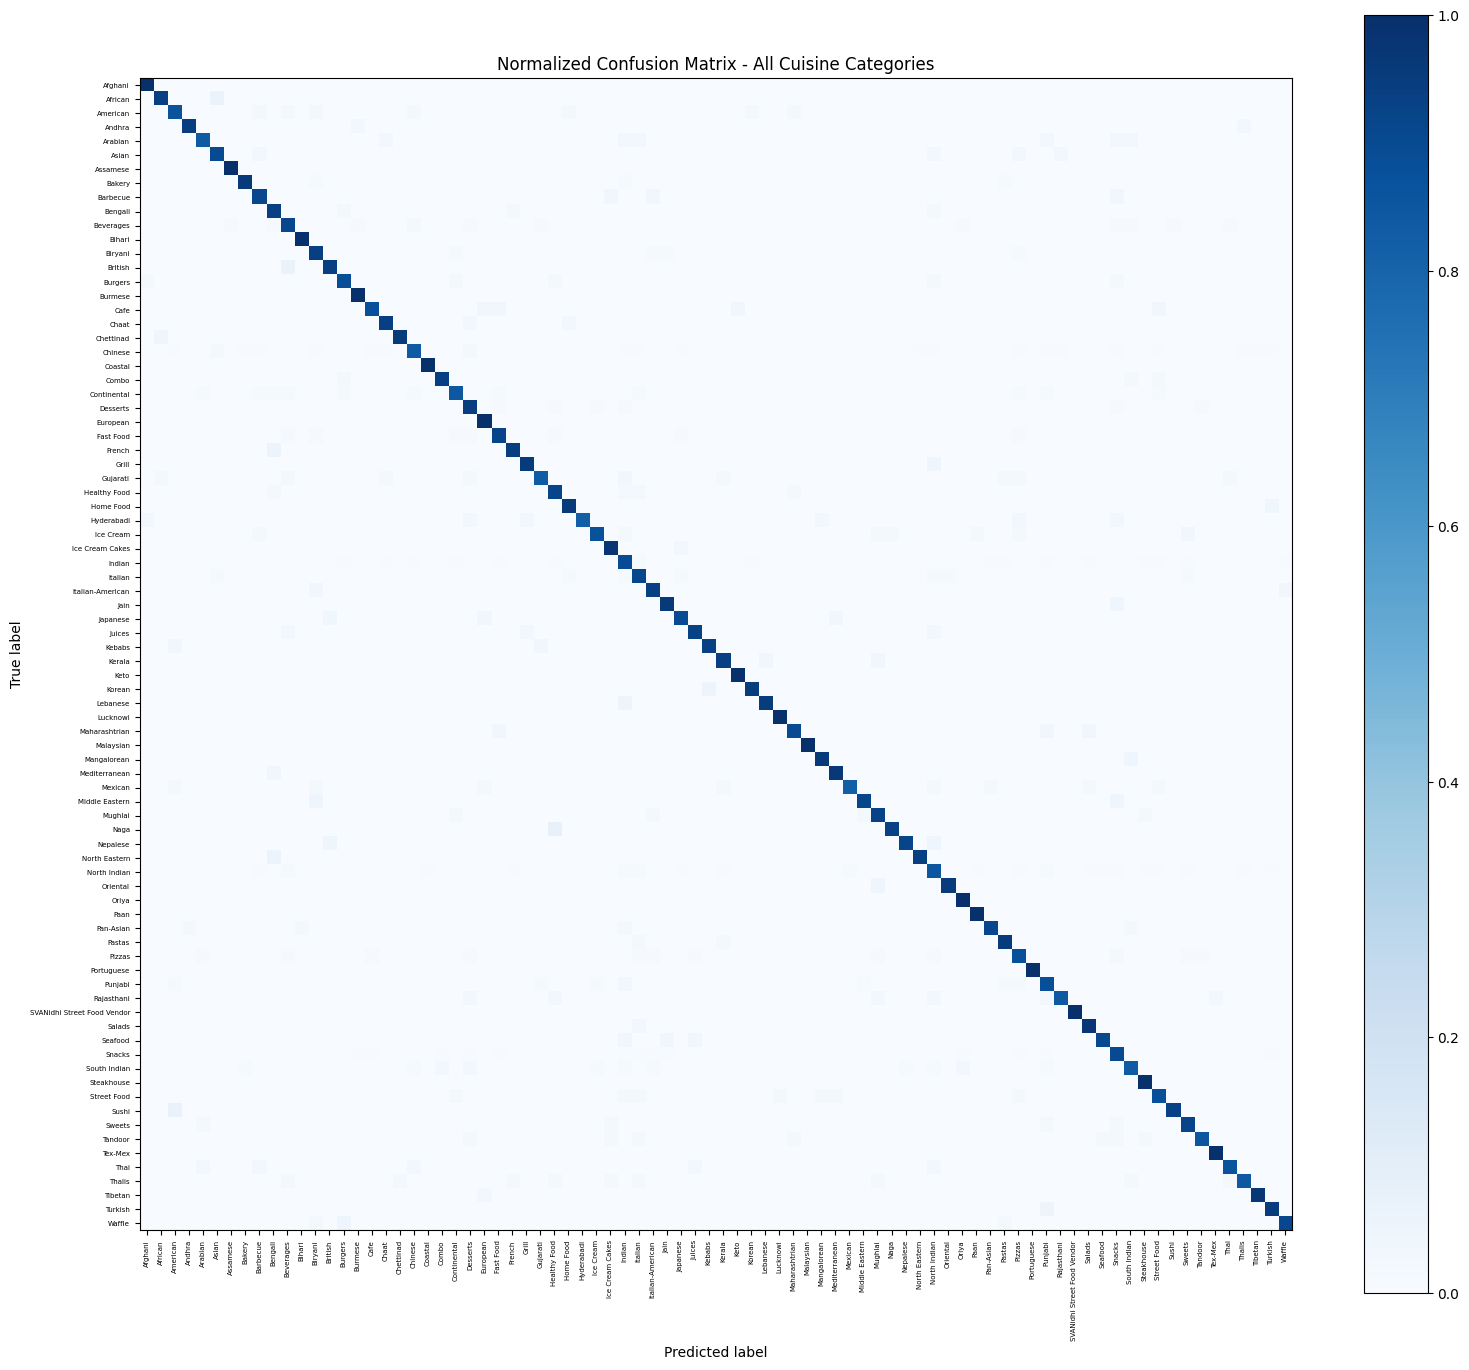

In [14]:
cm = confusion_matrix(
    y_test, y_pred, labels=range(len(label_encoder.classes_)), normalize="true"
)

figure, axis = plt.subplots(figsize=(16, 14))
display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_,
)
display.plot(
    ax=axis,
    cmap="Blues",
    include_values=False,
    xticks_rotation=90,
    colorbar=True,
)
axis.set_title("Normalized Confusion Matrix - All Cuisine Categories")
axis.tick_params(axis="both", labelsize=5)
plt.tight_layout()
plt.show()

## 11. Save the runtime model files

In [15]:
joblib.dump(final_model, MODELS_DIR / "cuisine_classifier.pkl")
joblib.dump(final_vectorizer, MODELS_DIR / "preprocessors.pkl")
joblib.dump(label_encoder, MODELS_DIR / "label_encoder.pkl")

print("Saved model files in:", MODELS_DIR)

Saved model files in: D:\The Intelligent Culinary Matchmaker & Personalized Menu Agent\culinary_matchmaker\models


## 12. Test one returning-user example

In [16]:
sample_user = {
    "meal_time": "Dinner",
    "day_type": "Weekend",
    "vegetarian": "Yes",
    "average_previous_rating": 4.4,
    "most_ordered_cuisine": "North Indian",
    "order_frequency": 12,
    "spice_preference": "Hot",
    "previous_cuisine_orders": 9,
}

sample_encoded = use_32_bit_indices(
    final_vectorizer.transform([sample_user])
)
probabilities = final_model.predict_proba(sample_encoded)[0]
class_names = label_encoder.inverse_transform(final_model.classes_)

prediction_table = pd.DataFrame({
    "cuisine": class_names,
    "probability": probabilities,
}).sort_values("probability", ascending=False).head(10)

prediction_table

,cuisine,probability
56,North Indian,0.693786
20,Coastal,0.020014
12,Biryani,0.014339
72,Street Food,0.012599
50,Mexican,0.011819
68,Seafood,0.011103
49,Mediterranean,0.010094
52,Mughlai,0.010084
42,Keto,0.008926
25,Fast Food,0.007675


## Conclusion

- The 5,000 synthetic users are training examples, not an allowed-user list.
- `user_id` groups historical records and separates users across data splits.
- The model learns from meal context and previous ordering behaviour.
- New users use onboarding preferences until they have at least 3 previous orders.